In [139]:
import xarray as xr

raw_cams = xr.open_dataset("~/projects/air-quality-downscaling/data/raw/cams/data_sfc.nc")

##### Working with broader CAMS reanalysis data, rather than the European reanalysis, which is finer resolution. I will work on it after having some working Proof of Concept here. 

In [140]:
raw_cams

<xarray.Dataset> Size: 38kB
Dimensions:     (valid_time: 365, latitude: 4, longitude: 6)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Data variables:
    pm2p5       (valid_time, latitude, longitude) float32 35kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T16:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [141]:
raw_cams["pm2p5"]

<xarray.DataArray 'pm2p5' (valid_time: 365, latitude: 4, longitude: 6)> Size: 35kB
[8760 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    kg m**-3
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [142]:
pm25 = raw_cams['pm2p5'] * 1e9 # Convert to ug/m3
pm25.attrs['units'] = 'µg/m³'  # update the units metadata 

In [143]:
pm25

<xarray.DataArray 'pm2p5' (valid_time: 365, latitude: 4, longitude: 6)> Size: 35kB
array([[[11.890847 , 15.525643 , 18.552782 , 23.632423 , 21.221468 ,
         11.829911 ],
        [15.815544 , 13.262934 , 15.654109 , 16.67138  , 13.55545  ,
          5.3112216],
        [11.101065 , 12.395731 , 14.412421 , 17.229809 , 13.186764 ,
          4.6420608],
        [ 7.0403986,  6.015739 ,  9.2967415, 12.806253 , 12.802048 ,
          5.7668786]],

       [[11.477482 , 13.910607 , 17.446724 , 23.115944 , 20.953394 ,
          4.8216863],
        [15.56134  , 14.490524 , 17.056437 , 16.669786 , 13.587737 ,
          7.3536057],
        [15.71425  , 15.102728 , 15.659339 , 14.213356 , 12.126747 ,
          9.140308 ],
        [10.073222 ,  9.568908 , 10.113467 , 10.054691 ,  9.16225  ,
          8.818006 ]],

       [[19.942434 , 15.59647  , 17.856451 , 16.502953 , 12.942451 ,
          6.5583096],
...
        [11.455086 ,  9.783662 ,  7.638846 ,  5.2959876,  3.6750407,
          2.0977495]],

       [[ 7.61861  , 10.39848  , 13.964609 , 18.981836 , 20.589823 ,
         12.128794 ],
        [13.349336 ,  9.880523 , 10.919848 ,  9.873247 ,  9.97511  ,
          8.53015  ],
        [15.622163 , 13.581939 , 11.115844 , 10.229769 ,  9.98125  ,
          9.693622 ],
        [10.726581 ,  8.544476 ,  8.235475 ,  8.271854 ,  8.745929 ,
          8.21592  ]],

       [[ 9.4808   ,  8.69079  ,  8.552433 , 14.317493 , 13.925842 ,
          6.442519 ],
        [16.294735 , 10.7120285,  8.8789425,  7.960921 ,  7.1750035,
          5.8819294],
        [16.310537 , 13.128783 , 10.5701475,  9.7650175,  9.626433 ,
          8.426241 ],
        [13.649583 ,  9.118594 ,  7.684207 ,  7.832568 ,  8.708412 ,
          8.500137 ]]], shape=(365, 4, 6), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [144]:
raw_cams['pm2p5'].sel(valid_time='2022-01-01')

<xarray.DataArray 'pm2p5' (latitude: 4, longitude: 6)> Size: 96B
array([[1.189085e-08, 1.552564e-08, 1.855278e-08, 2.363242e-08, 2.122147e-08,
        1.182991e-08],
       [1.581554e-08, 1.326293e-08, 1.565411e-08, 1.667138e-08, 1.355545e-08,
        5.311222e-09],
       [1.110106e-08, 1.239573e-08, 1.441242e-08, 1.722981e-08, 1.318676e-08,
        4.642061e-09],
       [7.040398e-09, 6.015739e-09, 9.296741e-09, 1.280625e-08, 1.280205e-08,
        5.766879e-09]], dtype=float32)
Coordinates:
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
    valid_time  datetime64[ns] 8B 2022-01-01
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    kg m**-3
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [145]:
pm25.sel(valid_time=slice('2022-01-01', '2022-03-31')) # Directly using pm25 variable now to call. Further, slicing a range of timeperiod

<xarray.DataArray 'pm2p5' (valid_time: 90, latitude: 4, longitude: 6)> Size: 9kB
array([[[ 11.890847 ,  15.525643 ,  18.552782 ,  23.632423 ,
          21.221468 ,  11.829911 ],
        [ 15.815544 ,  13.262934 ,  15.654109 ,  16.67138  ,
          13.55545  ,   5.3112216],
        [ 11.101065 ,  12.395731 ,  14.412421 ,  17.229809 ,
          13.186764 ,   4.6420608],
        [  7.0403986,   6.015739 ,   9.2967415,  12.806253 ,
          12.802048 ,   5.7668786]],

       [[ 11.477482 ,  13.910607 ,  17.446724 ,  23.115944 ,
          20.953394 ,   4.8216863],
        [ 15.56134  ,  14.490524 ,  17.056437 ,  16.669786 ,
          13.587737 ,   7.3536057],
        [ 15.71425  ,  15.102728 ,  15.659339 ,  14.213356 ,
          12.126747 ,   9.140308 ],
        [ 10.073222 ,   9.568908 ,  10.113467 ,  10.054691 ,
           9.16225  ,   8.818006 ]],

       [[ 19.942434 ,  15.59647  ,  17.856451 ,  16.502953 ,
          12.942451 ,   6.5583096],
...
        [ 45.3349   ,  21.284904 ,  22.528412 ,  25.252802 ,
          24.199152 ,  23.464054 ]],

       [[ 61.539597 ,  80.23914  ,  67.34399  ,  32.422916 ,
          27.386135 ,  30.7424   ],
        [ 66.20928  ,  55.14073  ,  48.64728  ,  39.514816 ,
          34.02852  ,  49.907272 ],
        [ 77.60969  ,  78.035324 ,  68.516785 ,  74.49819  ,
          78.210175 ,  87.49908  ],
        [ 80.71936  ,  87.9312   ,  88.15005  ,  97.27432  ,
         104.02607  , 104.84439  ]],

       [[ 44.266243 ,  36.08784  ,  31.108583 ,  31.122    ,
          41.121437 ,  45.906746 ],
        [ 34.37776  ,  25.610233 ,  26.58635  ,  31.99375  ,
          40.070744 ,  49.452637 ],
        [ 24.395832 ,  55.512146 ,  63.64803  ,  59.393414 ,
          57.718353 ,  64.722595 ],
        [ 28.7655   ,  77.71655  ,  83.19762  ,  69.210045 ,
          64.93861  ,  74.852776 ]]], shape=(90, 4, 6), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 720B 2022-01-01 ... 2022-03-31
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [146]:
pm25.sel(latitude=42.0, longitude=1.5) # The lat and long that we have in our data. Just writing here to get grip on the syntax of xarray package 

<xarray.DataArray 'pm2p5' (valid_time: 365)> Size: 1kB
array([ 15.654109 ,  17.056437 ,  16.689682 ,  12.230658 ,  13.10832  ,
         8.388269 ,  10.964869 ,   8.037432 ,   7.1420345,   6.145797 ,
         8.968527 ,  12.753844 ,  15.39695  ,  18.869741 ,  19.69147  ,
        19.594154 ,  17.804268 ,   8.688403 ,  19.344044 ,  17.508682 ,
        14.986768 ,  11.306383 ,  11.6083355,  14.053285 ,  18.423975 ,
        19.520485 ,  18.940228 ,  13.006683 ,  11.473276 ,  10.767281 ,
        14.070452 ,   6.8338294,   6.524715 ,  10.29855  ,  20.752281 ,
        14.243085 ,  13.412091 ,  11.617772 ,  11.588895 ,  11.895281 ,
        11.108341 ,  15.331579 ,  24.146856 ,  29.524927 ,  17.37044  ,
         7.393965 ,  10.647682 ,   8.976201 ,  14.406055 ,   6.4728737,
         9.891096 ,   9.675659 ,   8.544703 ,   9.894734 ,   9.371206 ,
        11.310476 ,   7.2193418,  10.164513 ,  15.303158 ,  19.475237 ,
        16.372725 ,  18.264473 ,  11.559678 ,   8.445568 ,   8.08177  ,
        16.520061 ,  17.973434 ,  13.178578 ,   9.622454 ,   5.143193 ,
         7.061317 ,  11.31366  ,  10.359144 ,   9.215455 ,  13.810677 ,
        14.340003 ,  61.010723 ,  48.10886  ,  58.662407 ,  68.40821  ,
        19.56073  ,  14.527359 ,  15.140699 ,  26.612839 ,  25.46585  ,
        56.395947 ,  49.9831   ,  44.383682 ,  48.64728  ,  26.58635  ,
        20.856306 ,   7.354174 ,  10.861186 ,  13.207682 ,  13.730641 ,
        15.434125 ,  13.244061 ,  10.156327 ,  10.846634 ,   8.747179 ,
...
         6.30871  ,   4.558842 ,   4.9496975,   8.580627 ,   8.191478 ,
         5.4710655,   7.8498487,   8.926577 ,   6.286882 ,  12.46417  ,
        16.91592  ,  18.644869 ,  11.209067 ,  20.472725 ,  12.107193 ,
         9.062887 ,   8.681013 ,   6.4503636,   6.8948793,   7.0131135,
        15.751538 ,  16.07441  ,  35.862286 ,  27.31781  ,  14.004968 ,
         5.3348684,  23.28011  ,  10.333224 ,  19.610184 ,  21.02115  ,
        20.604603 ,  25.269855 ,  22.483618 ,  17.574165 ,  31.183048 ,
         9.569363 ,  11.34822  ,   9.466703 ,   6.00528  ,   9.495125 ,
        11.010116 ,   7.404367 ,   8.583811 ,   8.067786 ,   9.360974 ,
         7.056997 ,  12.665624 ,   9.127461 ,  11.196562 ,   7.9799066,
         4.140475 ,   4.0763555,   6.182745 ,   5.5914598,   8.608595 ,
         6.661594 ,   3.612513 ,   9.682481 ,   6.850314 ,   5.4387784,
        12.884243 ,  10.957592 ,   7.689323 ,   9.321638 ,   6.024266 ,
         9.173505 ,  12.3501425,   7.5740447,  11.998395 ,  12.222528 ,
        11.935412 ,  12.667784 ,   4.225342 ,   6.1554604,   5.122331 ,
         6.5779204,   3.8834286,   6.0616684,   5.3846636,   2.6343515,
        10.186113 ,  11.101293 ,   6.772609 ,   6.0315413,   9.468977 ,
         5.647053 ,   6.389655 ,   6.6072516,  10.499434 ,   8.152256 ,
        13.50486  ,  12.88413  ,  10.241592 ,  10.919848 ,   8.8789425],
      dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
    latitude    float64 8B 42.0
    longitude   float64 8B 1.5
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [147]:
pm25.sel(latitude=41.6, longitude=1.2, method='nearest') #Putting a little bit different lat and long but using "method=nearest"


<xarray.DataArray 'pm2p5' (valid_time: 365)> Size: 1kB
array([14.412421 , 15.659339 , 16.705484 , 12.987129 , 12.106171 ,
        5.9358172,  4.033723 ,  7.2848253,  4.3326054,  6.205312 ,
        5.1788335,  5.4013753,  9.029577 , 12.337296 , 13.2740755,
       13.358658 , 15.539626 ,  7.154995 , 10.92576  , 16.942976 ,
       11.676888 ,  8.629968 ,  7.6204286,  8.558345 , 14.138778 ,
       12.577516 , 17.801767 , 14.389115 , 14.808393 ,  9.468522 ,
       12.477358 ,  5.7027593,  5.281436 , 10.053213 , 21.087204 ,
        9.721305 , 13.708814 ,  8.603706 ,  8.229392 ,  5.0854397,
        6.2799473, 11.123802 , 23.7103   , 17.725597 , 17.112598 ,
        6.207074 ,  6.433993 ,  7.063477 , 11.188206 ,  4.6679816,
        7.296535 ,  6.5911083,  8.156348 ,  8.619509 ,  8.406232 ,
        7.040171 ,  4.2857666,  7.3132467,  9.92668  ,  9.658152 ,
       11.539669 , 17.462526 ,  8.762072 ,  8.139977 ,  7.9235177,
       16.262674 , 14.340458 ,  9.456926 ,  5.3232727,  2.696197 ,
       10.502845 , 10.899839 , 10.664735 , 15.796558 , 17.140337 ,
       18.44387  , 73.7964   , 60.257095 , 73.634514 , 93.61633  ,
       21.641882 , 15.138539 , 11.641873 , 20.463516 , 28.758223 ,
       53.016266 , 40.39316  , 30.294586 , 68.516785 , 63.64803  ,
       20.991138 ,  7.0240273,  5.827587 , 11.757493 ,  8.711141 ,
       14.083526 ,  8.099959 ,  9.446921 ,  7.381459 ,  9.387577 ,
...
        5.406946 ,  2.955403 ,  4.1038675,  5.819629 ,  3.9404995,
        1.9416575,  5.410584 ,  4.9943767,  4.8055425,  8.67783  ,
       18.33473  , 23.294546 , 10.02627  , 16.422064 , 10.006374 ,
       10.19066  ,  6.0744014,  3.6279743,  5.8498697,  7.359631 ,
       15.362275 , 12.701549 , 32.154274 , 14.902071 , 22.806602 ,
        7.676249 , 20.729431 , 13.251338 , 20.103926 , 24.547604 ,
       13.852968 , 21.820143 , 34.160053 , 22.93018  , 36.025314 ,
        8.757411 , 12.948476 ,  7.479457 ,  6.092023 ,  4.2402916,
        7.1711383,  4.1916904,  6.3346305,  7.9827485,  5.4168367,
        5.797119 , 10.692474 ,  6.599521 ,  9.654627 ,  6.73208  ,
        3.6288838,  4.4183254,  4.8676157,  2.828415 ,  6.4983397,
        6.877599 ,  3.255991 ,  8.3473425,  6.4028425,  4.4592524,
        6.263974 , 13.319096 ,  6.224809 ,  6.575192 ,  3.5313406,
        5.9944797,  8.054144 ,  4.2152805,  7.9075446,  5.456741 ,
       11.701673 , 13.162321 ,  5.6739397,  5.0483775,  2.2897098,
        3.7614427,  5.7850685,  5.5127883,  4.7975845,  2.2733958,
        7.6104245,  9.906671 ,  4.4023523,  3.8889995,  9.633254 ,
        5.1882124,  4.9997196,  7.7111506,  8.655661 ,  8.556299 ,
       16.02848  , 13.062845 , 11.938254 , 11.115844 , 10.5701475],
      dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
    latitude    float64 8B 41.25
    longitude   float64 8B 1.5
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [148]:
#Let's check the data

pm25.mean() #Mean of all values in datetime, lat and long (one value)

<xarray.DataArray 'pm2p5' ()> Size: 4B
array(11.984062, dtype=float32)
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [149]:
pm25.mean(dim='valid_time') #mean of values in datetime but for lat and long (4,6) 

<xarray.DataArray 'pm2p5' (latitude: 4, longitude: 6)> Size: 96B
array([[12.945152, 13.502202, 13.732428, 13.098966, 11.830866,  8.532984],
       [14.312304, 14.265608, 14.690791, 12.808843, 10.678196,  8.406735],
       [14.7009  , 13.471184, 12.881903, 12.777918, 10.887648,  9.388444],
       [13.410029, 11.335858, 10.642969, 10.184606,  9.939233,  9.19172 ]],
      dtype=float32)
Coordinates:
  * latitude   (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude  (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [150]:
pm25.mean(dim='latitude') # mean while collapsing the latitude (365,6). Similarly for longitude. 

<xarray.DataArray 'pm2p5' (valid_time: 365, longitude: 6)> Size: 9kB
array([[11.461964 , 11.800013 , 14.479013 , 17.584967 , 15.191432 ,
         6.887518 ],
       [13.2065735, 13.268192 , 15.068992 , 16.013443 , 13.957532 ,
         7.5334015],
       [15.225226 , 14.8578615, 15.464366 , 12.523543 ,  8.92156  ,
         4.079325 ],
       ...,
       [12.610428 , 11.232884 , 10.228405 ,  9.651103 ,  8.888947 ,
         5.33521  ],
       [11.829172 , 10.601355 , 11.058944 , 11.839177 , 12.323029 ,
         9.642121 ],
       [13.933914 , 10.412549 ,  8.9214325,  9.969    ,  9.858923 ,
         7.312707 ]], shape=(365, 6), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

### If we want to check the statistics: 
##### pm25.mean(dim='valid_time')
##### pm25.max(dim='valid_time')
##### pm25.min(dim='valid_time')
##### pm25.std(dim='valid_time')
##### pm25.median(dim='valid_time')

In [151]:
monthly = pm25.resample(valid_time='ME').mean()

monthly

<xarray.DataArray 'pm2p5' (valid_time: 12, latitude: 4, longitude: 6)> Size: 1kB
array([[[12.604092 , 14.1338625, 15.390901 , 15.347125 , 13.4067   ,
          6.794303 ],
        [14.845829 , 13.099073 , 13.941768 , 12.776497 , 10.101193 ,
          5.6135163],
        [14.3497305, 13.246635 , 10.9984865, 10.139714 ,  8.29448  ,
          5.736516 ],
        [11.461553 ,  6.4446034,  6.138671 ,  5.5609555,  5.328841 ,
          4.573152 ]],

       [[13.396296 , 13.946775 , 13.625855 , 11.4191885,  9.9765215,
          6.511449 ],
        [12.997545 , 12.090627 , 12.282868 , 11.552445 ,  9.45733  ,
          6.0970473],
        [12.08159  , 10.509593 ,  9.522208 ,  9.302505 ,  7.9382315,
          6.1107774],
        [10.858933 ,  7.186738 ,  6.1744585,  5.1560197,  4.9218445,
          4.630008 ]],

       [[24.949652 , 24.556694 , 23.912193 , 22.21173  , 21.472574 ,
         18.518671 ],
...
        [13.275977 , 11.343947 , 12.349639 , 11.812495 , 11.376488 ,
         11.219566 ]],

       [[ 8.558594 ,  9.214634 ,  9.782696 ,  9.395846 ,  8.718202 ,
          5.6505485],
        [ 9.306749 ,  8.7742405,  9.0406475,  7.4047933,  6.070051 ,
          5.63986  ],
        [ 9.074697 ,  8.230094 ,  7.6694508,  7.492261 ,  6.541781 ,
          6.5759945],
        [ 7.8502903,  6.239535 ,  6.739358 ,  6.628598 ,  6.6983247,
          6.418432 ]],

       [[ 7.328966 ,  8.477273 ,  9.725915 , 10.6876   ,  9.675104 ,
          3.4132342],
        [ 9.904544 ,  8.107094 ,  8.428283 ,  7.151756 ,  5.3285613,
          3.1072447],
        [11.209045 ,  8.681187 ,  7.368844 ,  7.008463 ,  5.705509 ,
          4.074102 ],
        [ 9.061096 ,  5.5500646,  4.67038  ,  4.280616 ,  4.421381 ,
          3.9399421]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2022-01-31 ... 2022-12-31
  * latitude    (latitude) float64 32B 42.75 42.0 41.25 40.5
  * longitude   (longitude) float64 48B 0.0 0.75 1.5 2.25 3.0 3.75
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [152]:
# check for missing values
pm25.isnull().sum()

<xarray.DataArray 'pm2p5' ()> Size: 8B
array(0)
Attributes: (12/33)
    GRIB_paramId:                             210073
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      24
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 2.5 um
    units:                                    µg/m³
    standard_name:                            mass_concentration_of_pm2p5_amb...
    GRIB_number:                              0
    GRIB_surface:                             0.0

/home/hiten/projects/air-quality-downscaling/venv/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


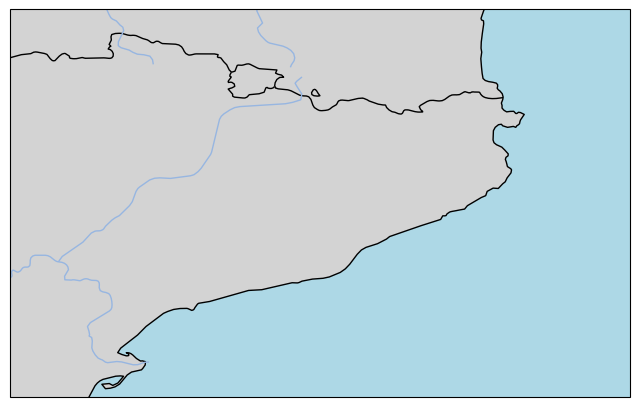

In [153]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection = ccrs.PlateCarree())

# add geographic features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor = "lightblue")
ax.add_feature(cfeature.RIVERS, facecolor = "lightblue")
ax.add_feature(cfeature.LAKES, facecolor = "lightblue")

# set map extent [west, east, south, north]
ax.set_extent([0.0, 4.0, 40.5, 43.0])


In [154]:
ccrs.PlateCarree()
# flat lat/lon — simplest
# good for small regions

ccrs.Mercator()
# web map style

<Projected CRS: +proj=merc +ellps=WGS84 +lon_0=0.0 +x_0=0.0 +y_0=0 ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Mercator (variant A)
Datum: Unknown based on WGS 84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Geographic features in cartopy

##### cfeature.COASTLINE
##### cfeature.BORDERS
##### cfeature.LAND
##### cfeature.OCEAN
##### cfeature.RIVERS
##### cfeature.LAKES

In [155]:
#Plotting for one day of CAMS Data

day = pm25.sel(valid_time='2022-01-01')

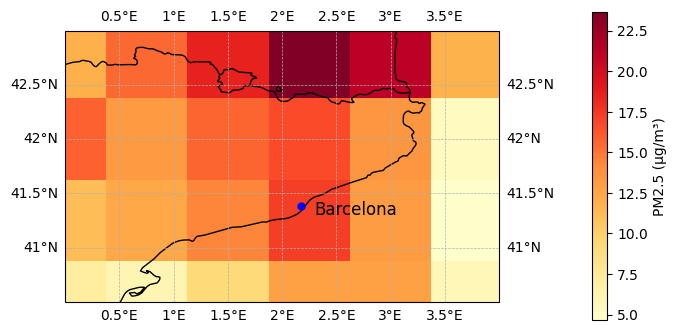

In [156]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection = ccrs.PlateCarree())

# add geographic features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor = "lightblue")
# ax.add_feature(cfeature.RIVERS, facecolor = "lightblue")
# ax.add_feature(cfeature.LAKES, facecolor = "lightblue")

# plot the data
mesh = ax.pcolormesh(
    day.longitude, day.latitude, day.values,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd',alpha=1
)

ax.plot(2.17, 41.38, 
        marker='o', color='blue', markersize=5,
        transform=ccrs.PlateCarree())
ax.text(2.3, 41.3, 'Barcelona', 
        transform=ccrs.PlateCarree(), fontsize=12)

# set map extent [west, east, south, north]
ax.set_extent([0.0, 4.0, 40.5, 43.0])

plt.colorbar(mesh, ax=ax, label='PM2.5 (µg/m³)',shrink=0.5, pad=0.15)

ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')

plt.show()

In [157]:
import pandas as pd

df_raw = pd.read_csv('data/raw/aqms/tasf-thgu.csv')
print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head()

(2926, 40)
['codi_eoi', 'nom_estacio', 'data', 'magnitud', 'contaminant', 'unitats', 'tipus_estacio', 'area_urbana', 'codi_ine', 'municipi', 'codi_comarca', 'nom_comarca', 'h01', 'h02', 'h03', 'h04', 'h05', 'h06', 'h07', 'h08', 'h09', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19', 'h20', 'h21', 'h22', 'h23', 'h24', 'altitud', 'latitud', 'longitud', 'geocoded_column']


,codi_eoi,nom_estacio,data,magnitud,contaminant,unitats,tipus_estacio,area_urbana,codi_ine,municipi,...,h19,h20,h21,h22,h23,h24,altitud,latitud,longitud,geocoded_column
0,43064001,Gandesa,2022-12-31T00:00:00.000,9,PM2.5,µg/m3,background,rural,43064,Gandesa,...,7.0,7.0,8.0,11.0,16.0,12.0,368,41.058212,0.439700,POINT (0.43969983 41.058212)
1,8196001,Sant Andreu de la Barca,2022-12-31T00:00:00.000,9,PM2.5,µg/m3,traffic,urban,8196,Sant Andreu de la Barca,...,15.0,14.0,13.0,13.0,14.0,16.0,40,41.450800,1.974900,POINT (1.9748996 41.4508)
2,43103001,Perafort (Puigdelfí),2022-12-31T00:00:00.000,9,PM2.5,µg/m3,industrial,rural,43103,Perafort,...,15.0,21.0,28.0,32.0,20.0,18.0,97,41.193604,1.236701,POINT (1.2367008 41.193604)
3,8019057,Barcelona (Palau Reial),2022-12-31T00:00:00.000,9,PM2.5,µg/m3,background,urban,8019,Barcelona,...,11.0,11.0,13.0,14.0,18.0,20.0,81,41.387490,2.115200,POINT (2.1151996 41.38749)
4,8112003,Manlleu,2022-12-31T00:00:00.000,9,PM2.5,µg/m3,background,suburban,8112,Manlleu,...,NaN,NaN,NaN,NaN,NaN,NaN,460,42.003307,2.287299,NaN


In [158]:
# filter for Barcelona area stations only
# our 4 stations are in: Barcelona, Sant Adrià de Besòs, Hospitalet, Vall d'Hebron
bcn_stations = df_raw[
    df_raw['municipi'].isin([
        'Barcelona', 
        'Sant Adrià de Besòs',
        "l'Hospitalet de Llobregat",
        'Hospitalet de Llobregat'
    ])
]

print(bcn_stations['nom_estacio'].unique())
print(f"\nShape: {bcn_stations.shape}")

<StringArray>
['Barcelona (Palau Reial)', 'Barcelona (Eixample)']
Length: 2, dtype: str

Shape: (366, 40)


In [159]:
print(df_raw['municipi'].unique())

<StringArray>
[                'Gandesa', 'Sant Andreu de la Barca',
                'Perafort',               'Barcelona',
                 'Manlleu',                'Igualada',
                    'Sort',    'Vilanova i la Geltrú',
       'Mollet del Vallès',                  'Girona',
               'Tarragona',                  'Lleida',
               'Vila-seca']
Length: 13, dtype: str


In [160]:
print(bcn_stations[['nom_estacio', 'latitud', 'longitud']].drop_duplicates())

                nom_estacio    latitud  longitud
3   Barcelona (Palau Reial)  41.387490    2.1152
12     Barcelona (Eixample)  41.385315    2.1538


In [161]:
print(df_raw['data'].unique()[:10])
print(f"Date range: {df_raw['data'].min()} to {df_raw['data'].max()}")

<StringArray>
['2022-12-31T00:00:00.000', '2022-12-30T00:00:00.000',
 '2022-12-29T00:00:00.000', '2022-12-28T00:00:00.000',
 '2022-12-27T00:00:00.000', '2022-12-26T00:00:00.000',
 '2022-12-25T00:00:00.000', '2022-12-24T00:00:00.000',
 '2022-12-23T00:00:00.000', '2022-12-22T00:00:00.000']
Length: 10, dtype: str
Date range: 2022-01-01T00:00:00.000 to 2022-12-31T00:00:00.000


In [162]:
# select only the columns we need
hour_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]

# compute daily mean across all 24 hours
bcn_stations = bcn_stations.copy()
bcn_stations['pm25_daily'] = bcn_stations[hour_cols].mean(axis=1)

# keep only relevant columns
df_aqms = bcn_stations[[
    'nom_estacio', 'data', 'latitud', 'longitud', 'pm25_daily'
]].reset_index(drop=True)

print(df_aqms.head(10))
print(f"\nShape: {df_aqms.shape}")

               nom_estacio                     data    latitud  longitud  \
0  Barcelona (Palau Reial)  2022-12-31T00:00:00.000  41.387490    2.1152   
1     Barcelona (Eixample)  2022-12-31T00:00:00.000  41.385315    2.1538   
2  Barcelona (Palau Reial)  2022-12-30T00:00:00.000  41.387490    2.1152   
3  Barcelona (Palau Reial)  2022-12-29T00:00:00.000  41.387490    2.1152   
4  Barcelona (Palau Reial)  2022-12-28T00:00:00.000  41.387490    2.1152   
5  Barcelona (Palau Reial)  2022-12-27T00:00:00.000  41.387490    2.1152   
6  Barcelona (Palau Reial)  2022-12-26T00:00:00.000  41.387490    2.1152   
7  Barcelona (Palau Reial)  2022-12-25T00:00:00.000  41.387490    2.1152   
8  Barcelona (Palau Reial)  2022-12-24T00:00:00.000  41.387490    2.1152   
9  Barcelona (Palau Reial)  2022-12-23T00:00:00.000  41.387490    2.1152   

   pm25_daily  
0    7.708333  
1         NaN  
2    6.166667  
3   10.958333  
4   15.333333  
5   11.904762  
6    9.750000  
7   12.041667  
8    4.000000  
9  

In [163]:
print(df_aqms.groupby('nom_estacio')['pm25_daily'].count())

nom_estacio
Barcelona (Eixample)         0
Barcelona (Palau Reial)    346
Name: pm25_daily, dtype: int64


In [164]:
# keep only Palau Reial and drop NaN rows
df_aqms = df_aqms[
    df_aqms['nom_estacio'] == 'Barcelona (Palau Reial)'
].dropna(subset=['pm25_daily']).reset_index(drop=True)

# convert date to proper datetime
df_aqms['data'] = pd.to_datetime(df_aqms['data'])

# rename for clarity
df_aqms = df_aqms.rename(columns={'data': 'date'})

print(df_aqms.shape)
print(df_aqms.dtypes)
print(df_aqms.head())

(346, 5)
nom_estacio               str
date           datetime64[us]
latitud               float64
longitud              float64
pm25_daily            float64
dtype: object
               nom_estacio       date   latitud  longitud  pm25_daily
0  Barcelona (Palau Reial) 2022-12-31  41.38749    2.1152    7.708333
1  Barcelona (Palau Reial) 2022-12-30  41.38749    2.1152    6.166667
2  Barcelona (Palau Reial) 2022-12-29  41.38749    2.1152   10.958333
3  Barcelona (Palau Reial) 2022-12-28  41.38749    2.1152   15.333333
4  Barcelona (Palau Reial) 2022-12-27  41.38749    2.1152   11.904762


In [165]:
df_aqms.to_csv('data/processed/aqms_barcelona_2022.csv', index=False)
print("Saved successfully")

Saved successfully


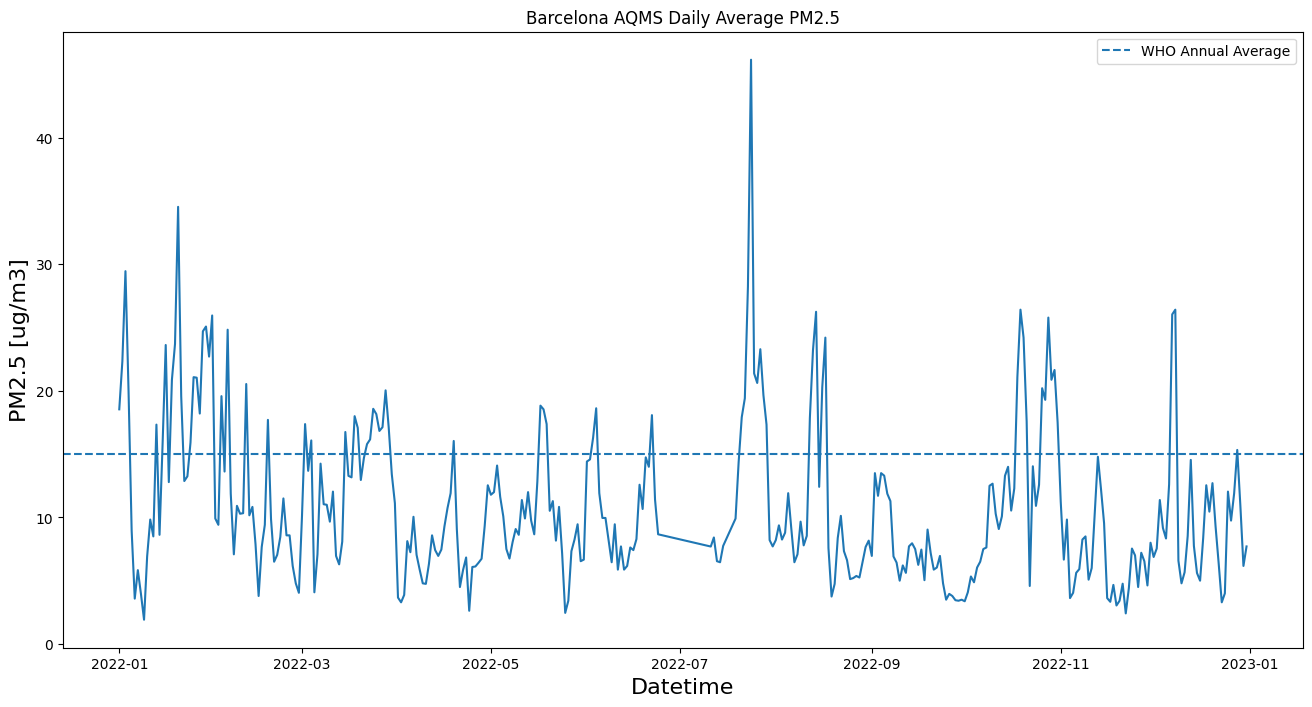

In [166]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,8))

plt.plot(df_aqms['date'],df_aqms["pm25_daily"])
plt.xlabel("Datetime",fontsize=16)
plt.ylabel("PM2.5 [ug/m3]",fontsize=16)
plt.title("Barcelona AQMS Daily Average PM2.5")
plt.axhline(15,linestyle="--",label="WHO Annual Average")

plt.legend()
plt.show()

In [167]:
# Matching XARRAY with AQMS data now.

In [168]:
station_lat = 41.38749
station_lon = 2.1152

cams_at_station = pm25.sel(
    latitude=station_lat,
    longitude=station_lon,
    method='nearest'
)

In [169]:
# Converting it to pandas

cams_df = cams_at_station.to_dataframe(name='pm25_cams').reset_index()
cams_df = cams_df.rename(columns={'valid_time': 'date'})

cams_df

,date,latitude,longitude,pm25_cams
0,2022-01-01,41.25,2.25,17.229809
1,2022-01-02,41.25,2.25,14.213356
2,2022-01-03,41.25,2.25,11.678309
3,2022-01-04,41.25,2.25,14.421175
4,2022-01-05,41.25,2.25,10.293093
...,...,...,...,...
360,2022-12-27,41.25,2.25,16.188324
361,2022-12-28,41.25,2.25,12.890950
362,2022-12-29,41.25,2.25,9.942596
363,2022-12-30,41.25,2.25,10.229769


In [170]:
df_aqms

,nom_estacio,date,latitud,longitud,pm25_daily
0,Barcelona (Palau Reial),2022-12-31,41.38749,2.1152,7.708333
1,Barcelona (Palau Reial),2022-12-30,41.38749,2.1152,6.166667
2,Barcelona (Palau Reial),2022-12-29,41.38749,2.1152,10.958333
3,Barcelona (Palau Reial),2022-12-28,41.38749,2.1152,15.333333
4,Barcelona (Palau Reial),2022-12-27,41.38749,2.1152,11.904762
...,...,...,...,...,...
341,Barcelona (Palau Reial),2022-01-05,41.38749,2.1152,8.952381
342,Barcelona (Palau Reial),2022-01-04,41.38749,2.1152,19.958333
343,Barcelona (Palau Reial),2022-01-03,41.38749,2.1152,29.458333
344,Barcelona (Palau Reial),2022-01-02,41.38749,2.1152,22.333333


In [171]:
df_merged = pd.merge (cams_df,df_aqms,on="date",how="inner")
df_merged

,date,latitude,longitude,pm25_cams,nom_estacio,latitud,longitud,pm25_daily
0,2022-01-01,41.25,2.25,17.229809,Barcelona (Palau Reial),41.38749,2.1152,18.541667
1,2022-01-02,41.25,2.25,14.213356,Barcelona (Palau Reial),41.38749,2.1152,22.333333
2,2022-01-03,41.25,2.25,11.678309,Barcelona (Palau Reial),41.38749,2.1152,29.458333
3,2022-01-04,41.25,2.25,14.421175,Barcelona (Palau Reial),41.38749,2.1152,19.958333
4,2022-01-05,41.25,2.25,10.293093,Barcelona (Palau Reial),41.38749,2.1152,8.952381
...,...,...,...,...,...,...,...,...
341,2022-12-27,41.25,2.25,16.188324,Barcelona (Palau Reial),41.38749,2.1152,11.904762
342,2022-12-28,41.25,2.25,12.890950,Barcelona (Palau Reial),41.38749,2.1152,15.333333
343,2022-12-29,41.25,2.25,9.942596,Barcelona (Palau Reial),41.38749,2.1152,10.958333
344,2022-12-30,41.25,2.25,10.229769,Barcelona (Palau Reial),41.38749,2.1152,6.166667


In [172]:
df_merged

,date,latitude,longitude,pm25_cams,nom_estacio,latitud,longitud,pm25_daily
0,2022-01-01,41.25,2.25,17.229809,Barcelona (Palau Reial),41.38749,2.1152,18.541667
1,2022-01-02,41.25,2.25,14.213356,Barcelona (Palau Reial),41.38749,2.1152,22.333333
2,2022-01-03,41.25,2.25,11.678309,Barcelona (Palau Reial),41.38749,2.1152,29.458333
3,2022-01-04,41.25,2.25,14.421175,Barcelona (Palau Reial),41.38749,2.1152,19.958333
4,2022-01-05,41.25,2.25,10.293093,Barcelona (Palau Reial),41.38749,2.1152,8.952381
...,...,...,...,...,...,...,...,...
341,2022-12-27,41.25,2.25,16.188324,Barcelona (Palau Reial),41.38749,2.1152,11.904762
342,2022-12-28,41.25,2.25,12.890950,Barcelona (Palau Reial),41.38749,2.1152,15.333333
343,2022-12-29,41.25,2.25,9.942596,Barcelona (Palau Reial),41.38749,2.1152,10.958333
344,2022-12-30,41.25,2.25,10.229769,Barcelona (Palau Reial),41.38749,2.1152,6.166667


In [173]:
df_merged = df_merged[['date', 'pm25_cams', 'pm25_daily']]
print(df_merged.head())

        date  pm25_cams  pm25_daily
0 2022-01-01  17.229809   18.541667
1 2022-01-02  14.213356   22.333333
2 2022-01-03  11.678309   29.458333
3 2022-01-04  14.421175   19.958333
4 2022-01-05  10.293093    8.952381


In [174]:
df_merged.describe()

,date,pm25_cams,pm25_daily
count,346,346.000000,346.000000
mean,2022-07-01 20:19:25.317918976,11.927382,10.827279
min,2022-01-01 00:00:00,1.643912,1.916667
25%,2022-03-28 06:00:00,6.096855,6.541667
50%,2022-06-22 12:00:00,9.130190,9.104167
75%,2022-10-05 18:00:00,13.896454,13.387500
max,2022-12-31 00:00:00,98.812279,46.166667
std,NaN,10.997939,6.158641


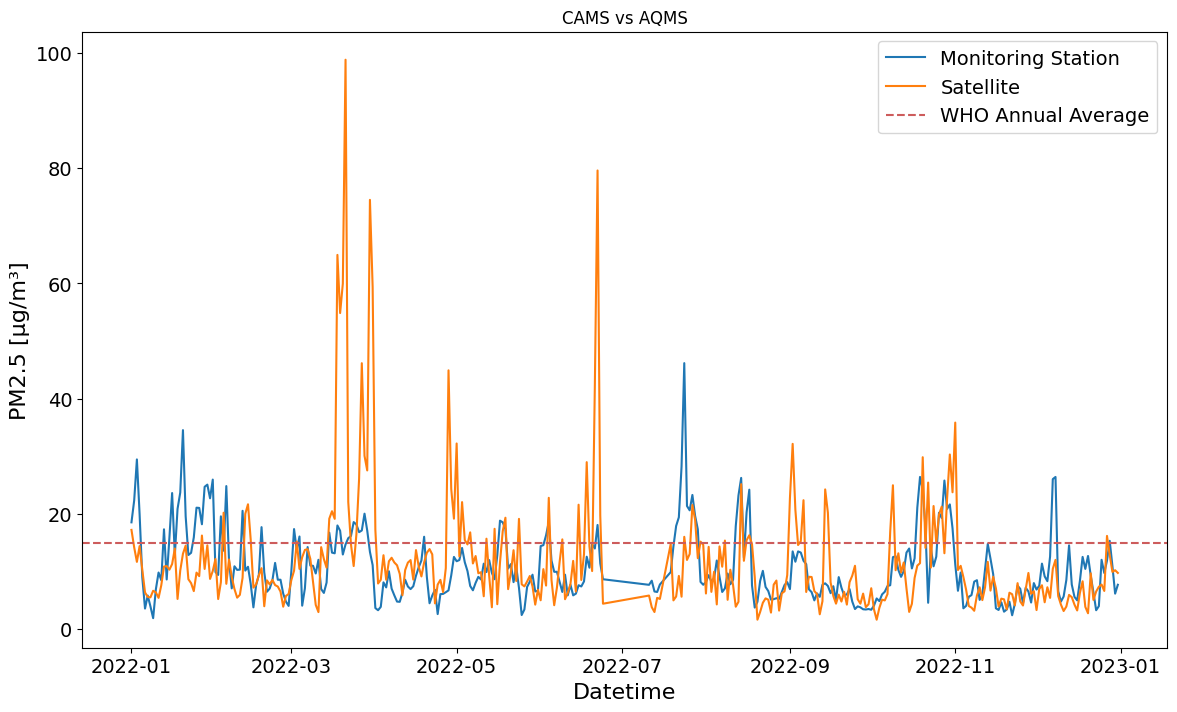

In [175]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14,8))

plt.plot(df_merged['date'],df_merged["pm25_daily"],label="Monitoring Station")
plt.plot(df_merged['date'],df_merged["pm25_cams"],label="Satellite")
plt.axhline(15,linestyle="--",color="indianred",label="WHO Annual Average")

plt.xlabel("Datetime",fontsize=16)
plt.ylabel("PM2.5 [μg/m³]",fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("CAMS vs AQMS")

plt.legend(fontsize=14)
plt.show()

In [176]:
import numpy as np
np.corrcoef(df_merged["pm25_daily"],df_merged["pm25_cams"])

array([[1.        , 0.28764222],
       [0.28764222, 1.        ]])

In [177]:
df_merged.to_csv('data/processed/merged_cams_aqms_2022.csv', index=False)
print("Saved successfully")

Saved successfully


In [178]:
# Now I will work on the model training. First the linear model to have a baseline.  

In [179]:
from sklearn.model_selection import train_test_split

X = df_merged["pm25_cams"].values.reshape(-1,1)
y = df_merged["pm25_daily"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [180]:
from sklearn.linear_model import LinearRegression

linearmodel = LinearRegression().fit(X_train,y_train)

y_pred = linearmodel.predict(X_test)


In [181]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f} µg/m³")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} µg/m³")

R²:   0.094
MAE:  4.212 µg/m³
RMSE: 6.340 µg/m³


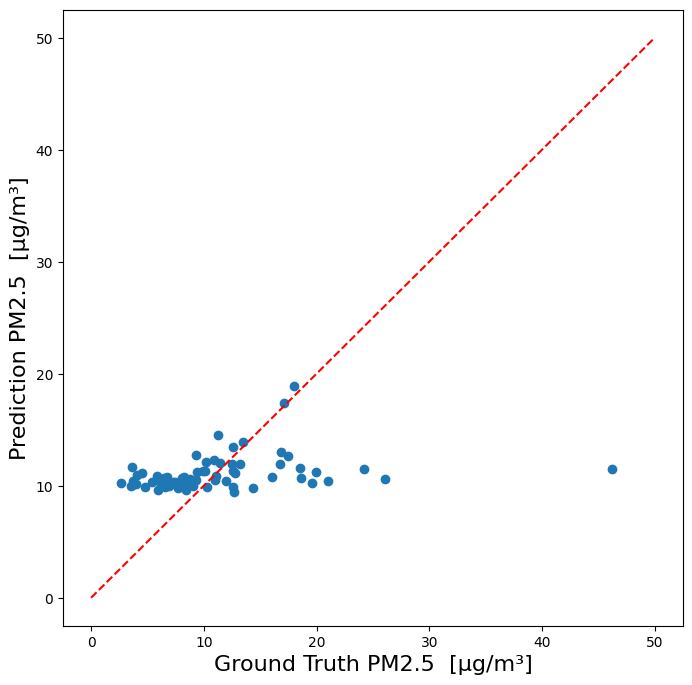

In [182]:
fig = plt.figure(figsize=(8,8))

plt.scatter(y_test,y_pred)
plt.plot([0, 50], [0, 50], '--', color='red', label='1:1 line')

plt.xlabel("Ground Truth PM2.5  [μg/m³]",fontsize=16)
plt.ylabel("Prediction PM2.5  [μg/m³]",fontsize=16)

plt.show()


#### Now I will try to add more features from the dataset that we have. I will add season using month filter
#### I will also use mlflow to track models. (Mlflow not compatible so made a dictionary to log)

In [183]:
# extract time features from date column
df_merged['month'] = df_merged['date'].dt.month
df_merged['day_of_year'] = df_merged['date'].dt.dayofyear
df_merged['season'] = df_merged['date'].dt.month.map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

In [184]:
season_map = {'winter': 0, 'spring': 1, 'summer': 2, 'autumn': 3}
df_merged['season_num'] = df_merged['season'].map(season_map)

In [185]:
df_merged

,date,pm25_cams,pm25_daily,month,day_of_year,season,season_num
0,2022-01-01,17.229809,18.541667,1,1,winter,0
1,2022-01-02,14.213356,22.333333,1,2,winter,0
2,2022-01-03,11.678309,29.458333,1,3,winter,0
3,2022-01-04,14.421175,19.958333,1,4,winter,0
4,2022-01-05,10.293093,8.952381,1,5,winter,0
...,...,...,...,...,...,...,...
341,2022-12-27,16.188324,11.904762,12,361,winter,0
342,2022-12-28,12.890950,15.333333,12,362,winter,0
343,2022-12-29,9.942596,10.958333,12,363,winter,0
344,2022-12-30,10.229769,6.166667,12,364,winter,0


In [186]:
# MLFLOW is not working with the current python version. To track the experiment runs, I will make a dictionary to append it with each run I guess. 
# I will log 3 metrics with each run. 20% test set. 

import pandas as pd

experiment_log = []

def log_run(run_name, features, y_test, y_pred):
    experiment_log.append({
        "run": run_name,
        "features": str(features),
        "r2": round(r2_score(y_test, y_pred), 3),
        "mae": round(mean_absolute_error(y_test, y_pred), 3),
        "rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)
    })
    print(f"R²:   {experiment_log[-1]['r2']}")
    print(f"MAE:  {experiment_log[-1]['mae']} µg/m³")
    print(f"RMSE: {experiment_log[-1]['rmse']} µg/m³")

def show_results():
    return pd.DataFrame(experiment_log).set_index("run")

In [187]:
log_run("baseline_cams_only", ["pm25_cams"], y_test, y_pred)

R²:   0.094
MAE:  4.212 µg/m³
RMSE: 6.34 µg/m³


##### Adding one more feature now (month)

In [188]:
from sklearn.model_selection import train_test_split

X = df_merged[["pm25_cams","month"]].values
y = df_merged["pm25_daily"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [189]:
from sklearn.linear_model import LinearRegression

linearmodel2 = LinearRegression().fit(X_train,y_train)

y_pred = linearmodel2.predict(X_test)


In [190]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f} µg/m³")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} µg/m³")

R²:   0.040
MAE:  4.333 µg/m³
RMSE: 6.526 µg/m³


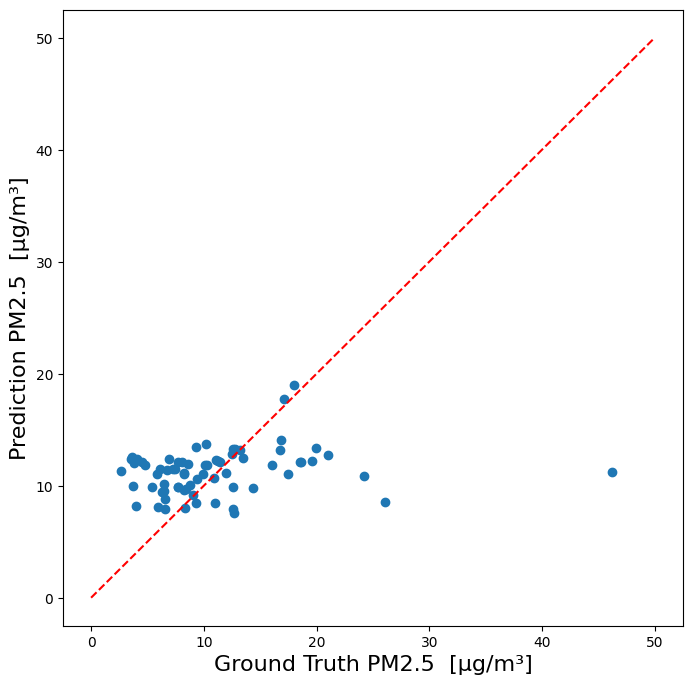

In [191]:
fig = plt.figure(figsize=(8,8))

plt.scatter(y_test,y_pred)
plt.plot([0, 50], [0, 50], '--', color='red', label='1:1 line')

plt.xlabel("Ground Truth PM2.5  [μg/m³]",fontsize=16)
plt.ylabel("Prediction PM2.5  [μg/m³]",fontsize=16)

plt.show()


In [192]:
log_run("baseline_cams_month", ["pm25_cams","month"], y_test, y_pred)

R²:   0.04
MAE:  4.333 µg/m³
RMSE: 6.526 µg/m³


##### Adding two more features now (month + season)

In [193]:
df_merged

,date,pm25_cams,pm25_daily,month,day_of_year,season,season_num
0,2022-01-01,17.229809,18.541667,1,1,winter,0
1,2022-01-02,14.213356,22.333333,1,2,winter,0
2,2022-01-03,11.678309,29.458333,1,3,winter,0
3,2022-01-04,14.421175,19.958333,1,4,winter,0
4,2022-01-05,10.293093,8.952381,1,5,winter,0
...,...,...,...,...,...,...,...
341,2022-12-27,16.188324,11.904762,12,361,winter,0
342,2022-12-28,12.890950,15.333333,12,362,winter,0
343,2022-12-29,9.942596,10.958333,12,363,winter,0
344,2022-12-30,10.229769,6.166667,12,364,winter,0


In [194]:
season_dummies = pd.get_dummies(df_merged['season'], prefix='season').astype(int)
df_merged = pd.concat([df_merged, season_dummies], axis=1)
df_merged

,date,pm25_cams,pm25_daily,month,day_of_year,season,season_num,season_autumn,season_spring,season_summer,season_winter
0,2022-01-01,17.229809,18.541667,1,1,winter,0,0,0,0,1
1,2022-01-02,14.213356,22.333333,1,2,winter,0,0,0,0,1
2,2022-01-03,11.678309,29.458333,1,3,winter,0,0,0,0,1
3,2022-01-04,14.421175,19.958333,1,4,winter,0,0,0,0,1
4,2022-01-05,10.293093,8.952381,1,5,winter,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
341,2022-12-27,16.188324,11.904762,12,361,winter,0,0,0,0,1
342,2022-12-28,12.890950,15.333333,12,362,winter,0,0,0,0,1
343,2022-12-29,9.942596,10.958333,12,363,winter,0,0,0,0,1
344,2022-12-30,10.229769,6.166667,12,364,winter,0,0,0,0,1


In [195]:
from sklearn.model_selection import train_test_split

X = df_merged[["pm25_cams","month","season_autumn","season_spring","season_summer","season_winter"]].values
y = df_merged["pm25_daily"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [196]:
from sklearn.linear_model import LinearRegression

linearmodel3 = LinearRegression().fit(X_train,y_train)

y_pred = linearmodel3.predict(X_test)


In [197]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f} µg/m³")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} µg/m³")

R²:   0.063
MAE:  4.467 µg/m³
RMSE: 6.448 µg/m³


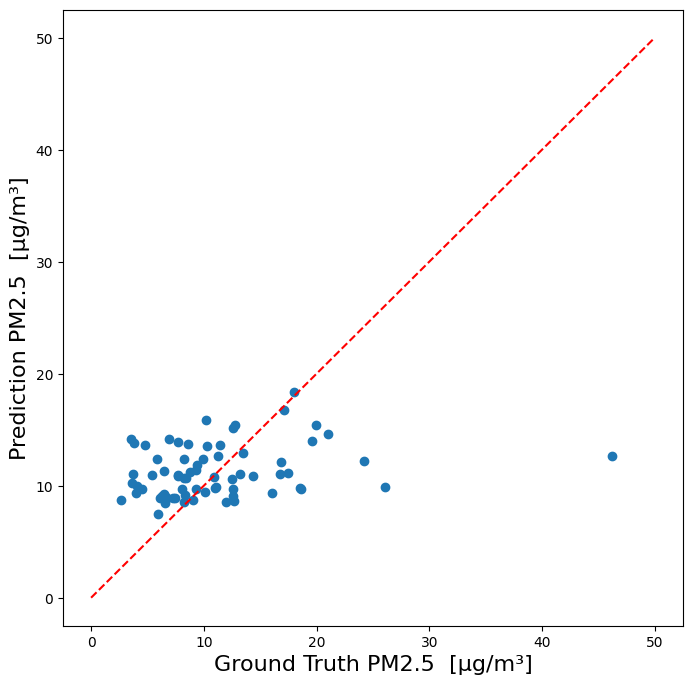

In [198]:
fig = plt.figure(figsize=(8,8))

plt.scatter(y_test,y_pred)
plt.plot([0, 50], [0, 50], '--', color='red', label='1:1 line')

plt.xlabel("Ground Truth PM2.5  [μg/m³]",fontsize=16)
plt.ylabel("Prediction PM2.5  [μg/m³]",fontsize=16)

plt.show()


In [199]:
log_run("baseline_cams_month_seasons", ["pm25_cams","month","season_autumn","season_spring","season_summer","season_winter"], y_test, y_pred)

R²:   0.063
MAE:  4.467 µg/m³
RMSE: 6.448 µg/m³


In [202]:
show_results()

,features,r2,mae,rmse
run,,,,
baseline_cams_only,['pm25_cams'],0.094,4.212,6.340
baseline_cams_month,"['pm25_cams', 'month']",0.040,4.333,6.526
baseline_cams_month_seasons,"['pm25_cams', 'month', 'season_autumn', 'seaso...",0.063,4.467,6.448


In [200]:
# Training Complex!!


In [201]:
# Conv NN
# Gaussian NN
# Kriging